# Building, Training, and Evaluating a Dense Neural Network with TensorFlow and Keras

This tutorial covers the steps to build, train, and evaluate a dense neural network using TensorFlow and Keras. We'll be working with the MNIST dataset of handwritten digits.


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


## 1 Importing Libraries and Data

First, we import TensorFlow, Keras, and other necessary libraries. The [MNIST](https://paperswithcode.com/dataset/mnist) dataset is a well-known collection of handwritten numbers used for machine learning and computer vision research. It consists of 70,000 grayscale images (1 color channel) of handwritten digits, each with a size of 28x28 pixels. The numbers are labeled with their corresponding numerical values, from 0 to 9. This dataset is directly available via the `tensorflow.keras.datasets` module.


In [2]:
# Load the data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In the next code cell we will plot a small random sample from the dataset. Run this code cell a few times to see several random examples.

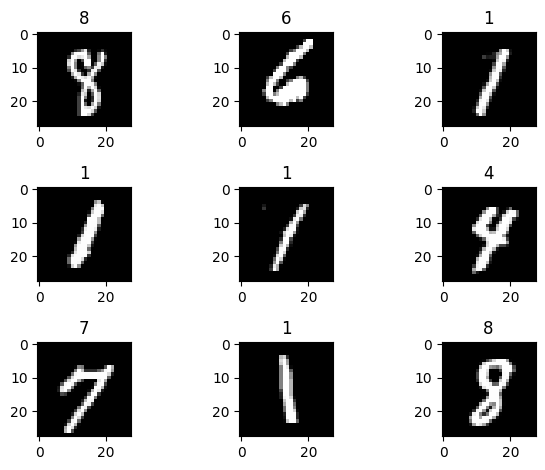

In [4]:
# Plot a random sample from the dataset
indices = np.random.choice(len(train_images), size=9, replace=False)

for count, value in enumerate(indices):
    plt.subplot(3, 3, count+1)
    plt.imshow(train_images[value], cmap="gray")
    plt.title(train_labels[value])

plt.tight_layout()
plt.show()

## 2 Data preprocessing

After we load the MNIST dataset, we normalize the pixel values to be between 0 and 1. This is because neural networks (and most machine learning models) train more efficiently with normalized data.

The data is 2 dimensional images, but dense neural networks take 1 dimensional input. So, we "flatten" the images to get a 1 dimensional array of pixels. Then we convert the labels into one-hot encoded vectors.

In [5]:
# Normalize the images.
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten the images.
train_images = train_images.reshape((-1, 784))
test_images = test_images.reshape((-1, 784))

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


## 3 Building the Dense Neural Network

We define a simple neural network architecture using Keras' Sequential model. It includes a dense layer with ReLU activation and an output layer with softmax activation. The number of neurons at the output layer = number of classes. The softmax activation converts the outputs to a list of probabilities that add up to 1. The output neuron with the highest probability (after training) gives the prediction.


In [6]:
# Build the model
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## 4 Training the Dense Neural Network

Now, we'll train our model on the training data, holding out a portion for validation.


In [7]:
# Train the model
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2)


Epoch 1/10
1500/1500 [==============================] - 16s 10ms/step - loss: 0.2225 - accuracy: 0.9352 - val_loss: 0.1363 - val_accuracy: 0.9593
Epoch 2/10
1500/1500 [==============================] - 15s 10ms/step - loss: 0.0903 - accuracy: 0.9723 - val_loss: 0.0897 - val_accuracy: 0.9730
Epoch 3/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.0564 - accuracy: 0.9820 - val_loss: 0.0833 - val_accuracy: 0.9755
Epoch 4/10
1500/1500 [==============================] - 11s 7ms/step - loss: 0.0407 - accuracy: 0.9872 - val_loss: 0.0847 - val_accuracy: 0.9754
Epoch 5/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.0296 - accuracy: 0.9902 - val_loss: 0.0826 - val_accuracy: 0.9773
Epoch 6/10
1500/1500 [==============================] - 11s 8ms/step - loss: 0.0201 - accuracy: 0.9936 - val_loss: 0.0853 - val_accuracy: 0.9782
Epoch 7/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.0183 - accuracy: 0.9937 - val_loss: 0.0949 - val_

## 5 Plotting the Loss Curves

We plot the training and validation loss and accuracy to monitor the learning process.


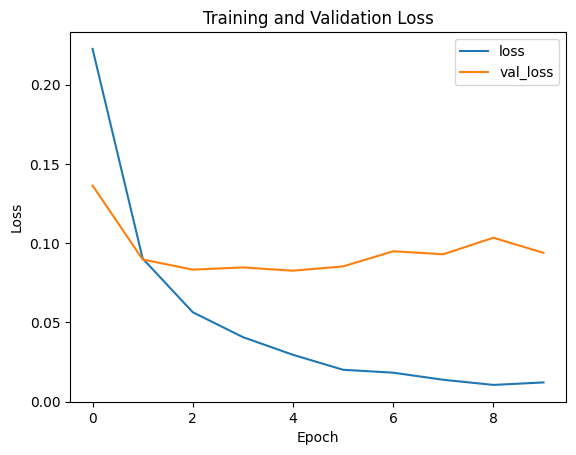

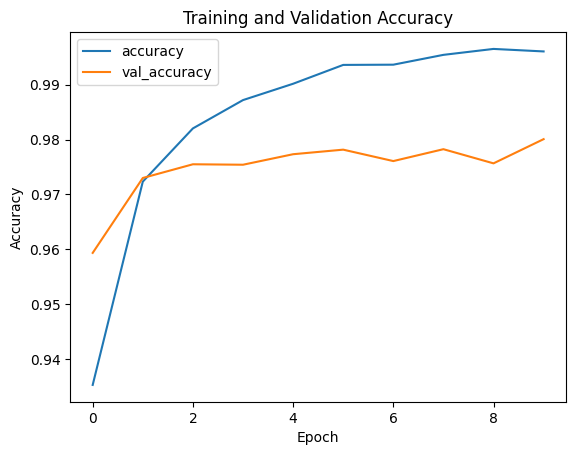

In [8]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 6 Evaluating the Model on the Test Set

Finally, we evaluate the model's performance on the test set.


In [9]:

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


313/313 [==============================] - 1s 3ms/step - loss: 0.0807 - accuracy: 0.9809
Test Loss: 0.08071219176054001
Test Accuracy: 0.98089998960495
